<a href="https://colab.research.google.com/github/Zamzam100/30-daya-python-programming/blob/master/Datascience.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             mean_squared_error, mean_absolute_error, r2_score)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [4]:
!ls /


bin		   datalab  kaggle  libx32  proc	       run   tmp
boot		   dev	    lib     media   python-apt	       sbin  tools
Concrete_Data.xls  etc	    lib32   mnt     python-apt.tar.xz  srv   usr
content		   home     lib64   opt     root	       sys   var


In [5]:
df_concrete = pd.read_excel('/Concrete_Data.xls')
print("Shape:", df_concrete.shape)
df_concrete.head()

Shape: (1030, 9)


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [6]:
df_concrete.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)  

In [7]:
df_concrete.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


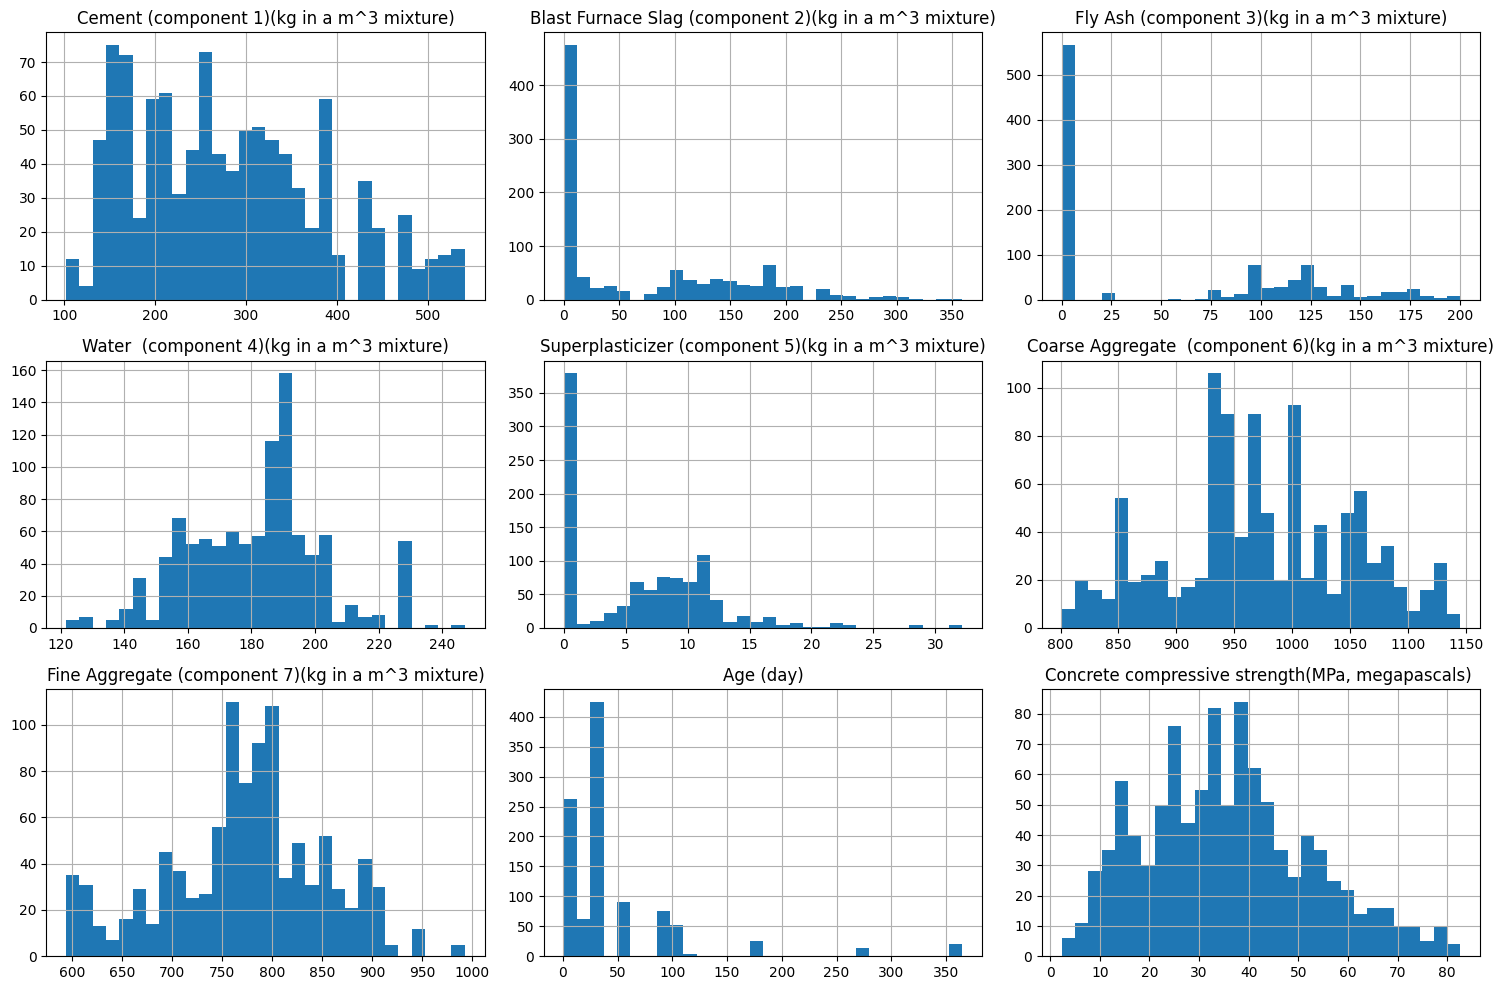

In [8]:
df_concrete.hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()

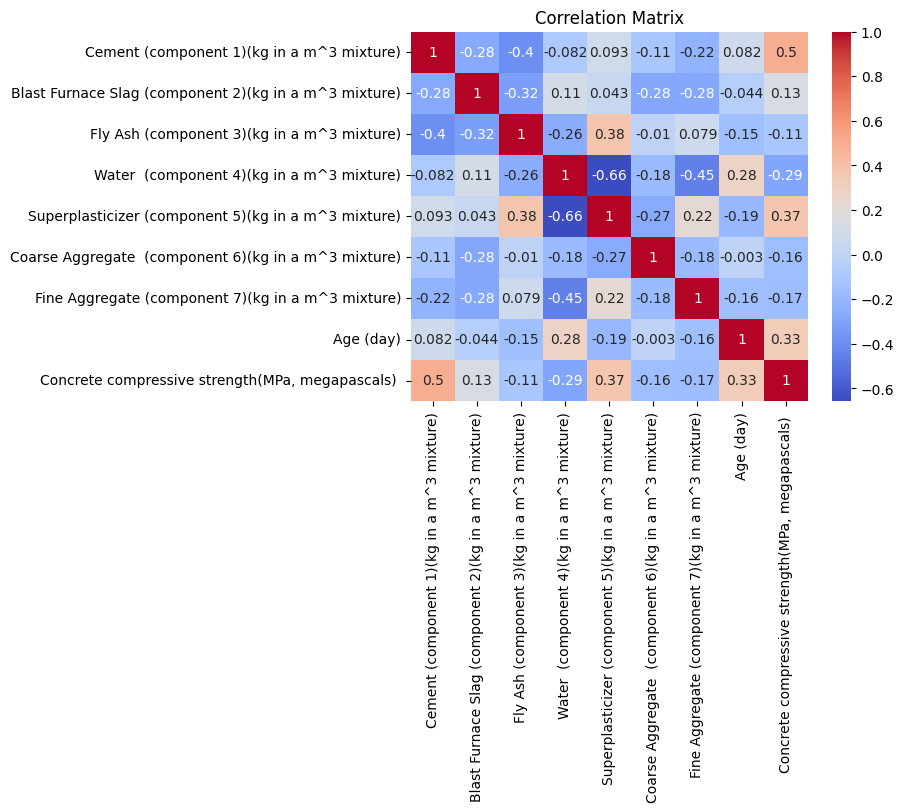

In [9]:
corr = df_concrete.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [10]:
# Separate features and target
X_conc = df_concrete.drop('Concrete compressive strength(MPa, megapascals) ', axis=1)
y_conc = df_concrete['Concrete compressive strength(MPa, megapascals) ']

# Train-test split
X_train_conc, X_test_conc, y_train_conc, y_test_conc = train_test_split(X_conc, y_conc, test_size=0.2, random_state=42)

# Scale features (important for Ridge and Lasso)
scaler_conc = StandardScaler()
X_train_conc_scaled = scaler_conc.fit_transform(X_train_conc)
X_test_conc_scaled = scaler_conc.transform(X_test_conc)

In [11]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_conc_scaled, y_train_conc)
y_pred_ridge = ridge.predict(X_test_conc_scaled)

print("Ridge Regression")
print("RMSE:", np.sqrt(mean_squared_error(y_test_conc, y_pred_ridge)))
print("MAE:", mean_absolute_error(y_test_conc, y_pred_ridge))
print("R2:", r2_score(y_test_conc, y_pred_ridge))

Ridge Regression
RMSE: 9.796410930619146
MAE: 7.7517614219393165
R2: 0.6275641808582495


In [12]:
lasso = Lasso(alpha=0.1, random_state=42)  # default alpha=1.0 might shrink too much
lasso.fit(X_train_conc_scaled, y_train_conc)
y_pred_lasso = lasso.predict(X_test_conc_scaled)

print("\nLasso Regression")
print("RMSE:", np.sqrt(mean_squared_error(y_test_conc, y_pred_lasso)))
print("MAE:", mean_absolute_error(y_test_conc, y_pred_lasso))
print("R2:", r2_score(y_test_conc, y_pred_lasso))


Lasso Regression
RMSE: 9.819122220314219
MAE: 7.8226650571292735
R2: 0.6258353226823946


In [13]:
# Ridge coefficients
coef_ridge = ridge.coef_
# Lasso coefficients
coef_lasso = lasso.coef_

features = X_conc.columns
coef_df = pd.DataFrame({'feature': features, 'Ridge': coef_ridge, 'Lasso': coef_lasso})
print(coef_df)

                                             feature      Ridge      Lasso
0          Cement (component 1)(kg in a m^3 mixture)  12.559741  10.721163
1  Blast Furnace Slag (component 2)(kg in a m^3 m...   9.213632   7.399886
2         Fly Ash (component 3)(kg in a m^3 mixture)   5.061598   3.452688
3          Water  (component 4)(kg in a m^3 mixture)  -3.038873  -4.240381
4  Superplasticizer (component 5)(kg in a m^3 mix...   1.842780   1.789434
5  Coarse Aggregate  (component 6)(kg in a m^3 mi...   1.248667  -0.000000
6  Fine Aggregate (component 7)(kg in a m^3 mixture)   1.751912   0.077530
7                                          Age (day)   7.018837   6.812914


In [14]:
# Ridge tuning
param_ridge = {'alpha': [0.01, 0.1, 1, 10, 100]}
grid_ridge = GridSearchCV(Ridge(random_state=42), param_ridge, cv=5, scoring='r2')
grid_ridge.fit(X_train_conc_scaled, y_train_conc)
print("Best alpha for Ridge:", grid_ridge.best_params_)
best_ridge = grid_ridge.best_estimator_

# Lasso tuning
param_lasso = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
grid_lasso = GridSearchCV(Lasso(random_state=42, max_iter=10000), param_lasso, cv=5, scoring='r2')
grid_lasso.fit(X_train_conc_scaled, y_train_conc)
print("Best alpha for Lasso:", grid_lasso.best_params_)
best_lasso = grid_lasso.best_estimator_

# Evaluate tuned models
y_pred_best_ridge = best_ridge.predict(X_test_conc_scaled)
y_pred_best_lasso = best_lasso.predict(X_test_conc_scaled)

print("\nTuned Ridge - RMSE:", np.sqrt(mean_squared_error(y_test_conc, y_pred_best_ridge)), "R2:", r2_score(y_test_conc, y_pred_best_ridge))
print("Tuned Lasso - RMSE:", np.sqrt(mean_squared_error(y_test_conc, y_pred_best_lasso)), "R2:", r2_score(y_test_conc, y_pred_best_lasso))

Best alpha for Ridge: {'alpha': 1}
Best alpha for Lasso: {'alpha': 0.001}

Tuned Ridge - RMSE: 9.796410930619146 R2: 0.6275641808582495
Tuned Lasso - RMSE: 9.796663048873667 R2: 0.627545010760634


In [16]:
df_med = pd.read_csv('/KaggleV2-May-2016.csv')
print("Shape:", df_med.shape)
df_med.head()

Shape: (110527, 14)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [17]:
# Basic info
df_med.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [18]:
# Convert target to binary
df_med['No-show'] = df_med['No-show'].map({'Yes':1, 'No':0})

# Summary statistics
df_med.describe(include='all')

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
count,1.105270e+05,1.105270e+05,110527,110527,110527,110527.000000,110527,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
unique,NaN,NaN,2,103549,27,NaN,81,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,F,2016-05-06T07:09:54Z,2016-06-06T00:00:00Z,NaN,JARDIM CAMBURI,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,71840,24,4692,NaN,7717,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.474963e+14,5.675305e+06,NaN,NaN,NaN,37.088874,NaN,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026,0.201933
std,2.560949e+14,7.129575e+04,NaN,NaN,NaN,23.110205,NaN,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873,0.401444
min,3.921784e+04,5.030230e+06,NaN,NaN,NaN,-1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,NaN,NaN,NaN,18.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,NaN,NaN,NaN,37.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,NaN,NaN,NaN,55.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000


In [19]:
df_med[df_med['Age'] < 0]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
99832,4.659432e+14,5775010,F,2016-06-06T08:58:13Z,2016-06-06T00:00:00Z,-1,ROMÃO,0,0,0,0,0,0,0


In [20]:
# Remove invalid age
df_med = df_med[df_med['Age'] >= 0]

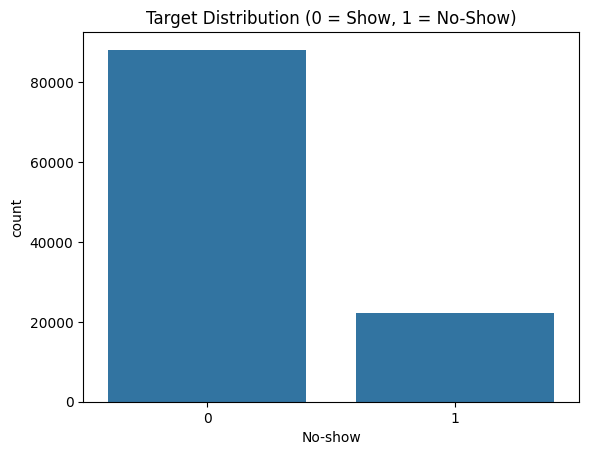

No-show
0    0.798066
1    0.201934
Name: proportion, dtype: float64


In [21]:
sns.countplot(x='No-show', data=df_med)
plt.title('Target Distribution (0 = Show, 1 = No-Show)')
plt.show()
print(df_med['No-show'].value_counts(normalize=True))

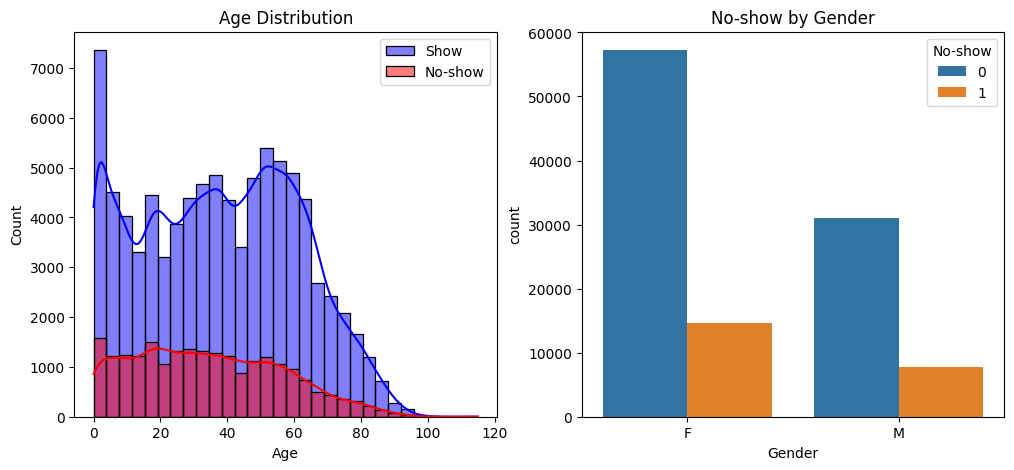

In [22]:
# Age distribution by target
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_med[df_med['No-show']==0]['Age'], bins=30, color='blue', label='Show', kde=True)
sns.histplot(df_med[df_med['No-show']==1]['Age'], bins=30, color='red', label='No-show', kde=True)
plt.legend()
plt.title('Age Distribution')

# Gender vs No-show
plt.subplot(1,2,2)
sns.countplot(x='Gender', hue='No-show', data=df_med)
plt.title('No-show by Gender')
plt.show()

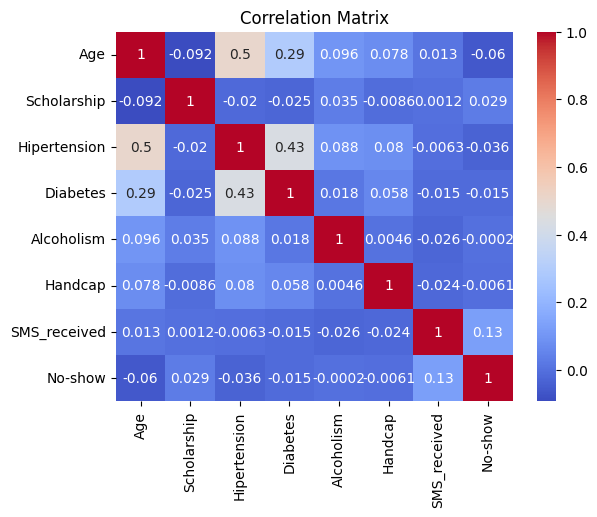

In [23]:
# Correlation of numeric features
numeric_cols = ['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received']
corr = df_med[numeric_cols + ['No-show']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [24]:
# Drop identifiers and datetime columns (not useful for simple models)
df_med.drop(['PatientId', 'AppointmentID', 'ScheduledDay', 'AppointmentDay', 'Neighbourhood'], axis=1, inplace=True)

# Encode Gender
le = LabelEncoder()
df_med['Gender'] = le.fit_transform(df_med['Gender'])  # F=0, M=1

# Separate features and target
X_med = df_med.drop('No-show', axis=1)
y_med = df_med['No-show']

# Train-test split
X_train_med, X_test_med, y_train_med, y_test_med = train_test_split(X_med, y_med, test_size=0.2, random_state=42, stratify=y_med)

# Scale features (important for Logistic Regression and Linear SVC)
scaler_med = StandardScaler()
X_train_med_scaled = scaler_med.fit_transform(X_train_med)
X_test_med_scaled = scaler_med.transform(X_test_med)

In [25]:
# Default hyperparameters
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_med_scaled, y_train_med)
y_pred_lr = lr.predict(X_test_med_scaled)
y_proba_lr = lr.predict_proba(X_test_med_scaled)[:,1]

print("Logistic Regression Performance")
print("Accuracy:", accuracy_score(y_test_med, y_pred_lr))
print("Precision:", precision_score(y_test_med, y_pred_lr))
print("Recall:", recall_score(y_test_med, y_pred_lr))
print("F1-score:", f1_score(y_test_med, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test_med, y_proba_lr))
print(confusion_matrix(y_test_med, y_pred_lr))

Logistic Regression Performance
Accuracy: 0.7980638740613408
Precision: 0.0
Recall: 0.0
F1-score: 0.0
ROC-AUC: 0.5998249635624339
[[17642     0]
 [ 4464     0]]


In [26]:
# LinearSVC uses squared hinge loss; we need to set dual=False for large dataset
svc = LinearSVC(random_state=42, max_iter=2000, dual=False)
svc.fit(X_train_med_scaled, y_train_med)
y_pred_svc = svc.predict(X_test_med_scaled)
# For ROC-AUC we need decision function scores
y_score_svc = svc.decision_function(X_test_med_scaled)

print("Linear SVC Performance")
print("Accuracy:", accuracy_score(y_test_med, y_pred_svc))
print("Precision:", precision_score(y_test_med, y_pred_svc))
print("Recall:", recall_score(y_test_med, y_pred_svc))
print("F1-score:", f1_score(y_test_med, y_pred_svc))
print("ROC-AUC:", roc_auc_score(y_test_med, y_score_svc))
print(confusion_matrix(y_test_med, y_pred_svc))

Linear SVC Performance
Accuracy: 0.7980638740613408
Precision: 0.0
Recall: 0.0
F1-score: 0.0
ROC-AUC: 0.5998071104756123
[[17642     0]
 [ 4464     0]]


In [27]:
# Feature importance from Logistic Regression
coef_lr = lr.coef_[0]
features = X_med.columns
importance_lr = pd.DataFrame({'feature': features, 'coefficient': coef_lr}).sort_values('coefficient', key=abs, ascending=False)
print("Logistic Regression coefficients (scaled features):")
print(importance_lr)

# For Linear SVC
coef_svc = svc.coef_[0]
importance_svc = pd.DataFrame({'feature': features, 'coefficient': coef_svc}).sort_values('coefficient', key=abs, ascending=False)
print("\nLinear SVC coefficients (scaled features):")
print(importance_svc)

Logistic Regression coefficients (scaled features):
        feature  coefficient
7  SMS_received     0.298679
1           Age    -0.160633
2   Scholarship     0.051347
5    Alcoholism     0.027731
4      Diabetes     0.017369
3  Hipertension    -0.016238
0        Gender    -0.012520
6       Handcap     0.007285

Linear SVC coefficients (scaled features):
        feature  coefficient
7  SMS_received     0.100694
1           Age    -0.050061
2   Scholarship     0.017158
5    Alcoholism     0.008379
4      Diabetes     0.004954
3  Hipertension    -0.004098
0        Gender    -0.003672
6       Handcap     0.002323


In [28]:
# Logistic Regression tuning
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100]}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid_lr, cv=5, scoring='roc_auc')
grid_lr.fit(X_train_med_scaled, y_train_med)
print("Best C for Logistic Regression:", grid_lr.best_params_)
best_lr = grid_lr.best_estimator_

# Linear SVC tuning
param_grid_svc = {'C': [0.01, 0.1, 1, 10, 100]}
grid_svc = GridSearchCV(LinearSVC(max_iter=2000, random_state=42, dual=False), param_grid_svc, cv=5, scoring='roc_auc')
grid_svc.fit(X_train_med_scaled, y_train_med)
print("Best C for Linear SVC:", grid_svc.best_params_)
best_svc = grid_svc.best_estimator_

# Evaluate tuned models
y_pred_best_lr = best_lr.predict(X_test_med_scaled)
y_proba_best_lr = best_lr.predict_proba(X_test_med_scaled)[:,1]
y_score_best_svc = best_svc.decision_function(X_test_med_scaled)

print("\nTuned Logistic Regression ROC-AUC:", roc_auc_score(y_test_med, y_proba_best_lr))
print("Tuned Linear SVC ROC-AUC:", roc_auc_score(y_test_med, y_score_best_svc))

Best C for Logistic Regression: {'C': 1}
Best C for Linear SVC: {'C': 10}

Tuned Logistic Regression ROC-AUC: 0.5998249635624339
Tuned Linear SVC ROC-AUC: 0.5998071104756123
